# Exploratory Data Analysis (EDA) — Refined

## Project Overview
This is a **trimmed-down version** of the original EDA notebook, refined specifically for portfolio use.

The full exploratory work (11 charts + extra tables) has been narrowed to the **7 charts that carry the most signal** for a public-facing Streamlit dashboard, plus a **Key Metrics** summary that maps directly to dashboard metric cards.

### What changed from the original notebook
**Kept (dashboard-ready):**
- Key Metrics summary (new)
- Salary Distribution
- Salary by Job Role
- Job Role Distribution
- Top Skills Required
- Top Hiring States
- Experience Required
- Remote vs In-Person

**Removed from the dashboard set (kept as supplementary analysis only, at the bottom):**
- Correlation Heatmap — too technical for a general dashboard audience
- Highest Paying Roles / States tables — not visual, redundant with the boxplot and states chart

**Dropped entirely:**
- Company Age Distribution — weak signal, low interpretive value
- Seniority Level Distribution — mostly "Not Specified", overlaps with Job Role chart
- Duplicate skills table — repeated the skills bar chart

Each chart below is tagged so you know exactly what to port into `app.py` for the Streamlit dashboard.


## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
pd.set_option("display.max_columns", None)


## Load Dataset

Update the path below to point to your `featured_jobs.csv` output from the feature engineering notebook.

In [2]:
df = pd.read_csv("C:/Users/ASAITHAMBI/OneDrive/Documents/dsjob_eda/data/featured_jobs.csv")
df.head()


,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Per_Hour,Employer_Provided,Min_Salary,Max_Salary,Avg_Salary,Company_Age,Job_State,Job_Simplified,Seniority,Python_yn,Java_yn,R_yn,SQL_yn,Cpp_yn,JavaScript_yn,Ruby_yn,Perl_yn,Scala_yn,Go_yn,AWS_yn,Azure_yn,Spark_yn,Hadoop_yn,Docker_yn,Kubernetes_yn,Tableau_yn,Power_BI_yn,Machine_Learning_yn,Big_Data_yn,Remote_Job,Years_Experience,Experience_Group
0,Data Scientist,53-91,"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),-1,0,0,53,91,72.0,50.0,NM,Data Scientist,Not Specified,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,NaN,Unknown
1,Healthcare Data Scientist,63-112,What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,0,0,63,112,87.5,39.0,MD,Data Scientist,Not Specified,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,3.0,3-5 Years
2,Data Scientist,80-90,"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,Security Services,Business Services,$100 to $500 million (USD),-1,0,0,80,90,85.0,13.0,FL,Data Scientist,Not Specified,1,0,1,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,3.0,3-5 Years
3,Data Scientist,56-97,*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),"Oak Ridge National Laboratory, National Renewa...",0,0,56,97,76.5,58.0,WA,Data Scientist,Not Specified,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1.0,0-2 Years
4,Data Scientist,86-143,Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",0,0,86,143,114.5,25.0,NY,Data Scientist,Not Specified,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,NaN,Unknown


## Color Palette

Streamlined to the shades actually used below.

In [3]:
purple_colors = {
    "dark_purple": "#4B0082",
    "mauve": "#9370DB",
    "light_violet": "#C8A2C8",
}


## 📊 Key Metrics (Dashboard Header Cards)

These four numbers are what viewers see first — perfect for `st.metric()` cards at the top of the Streamlit app.

In [4]:
total_jobs = len(df)
avg_salary = round(df["Avg_Salary"].mean(), 1)
avg_rating = round(df["Rating"].mean(), 2)
pct_remote = round(df["Remote_Job"].mean() * 100, 1)
top_skill = (
    df.filter(regex="_yn$")
    .sum()
    .sort_values(ascending=False)
    .index[0]
    .replace("_yn", "")
)

print(f"Total Job Listings : {total_jobs}")
print(f"Average Salary (K USD) : {avg_salary}")
print(f"Average Company Rating : {avg_rating}")
print(f"Percent Remote : {pct_remote}%")
print(f"Top Requested Skill : {top_skill}")


Total Job Listings : 467
Average Salary (K USD) : 101.0
Average Company Rating : 3.65
Percent Remote : 4.3%
Top Requested Skill : Python


## 📊 Chart 1 — Salary Distribution
*Dashboard-ready*

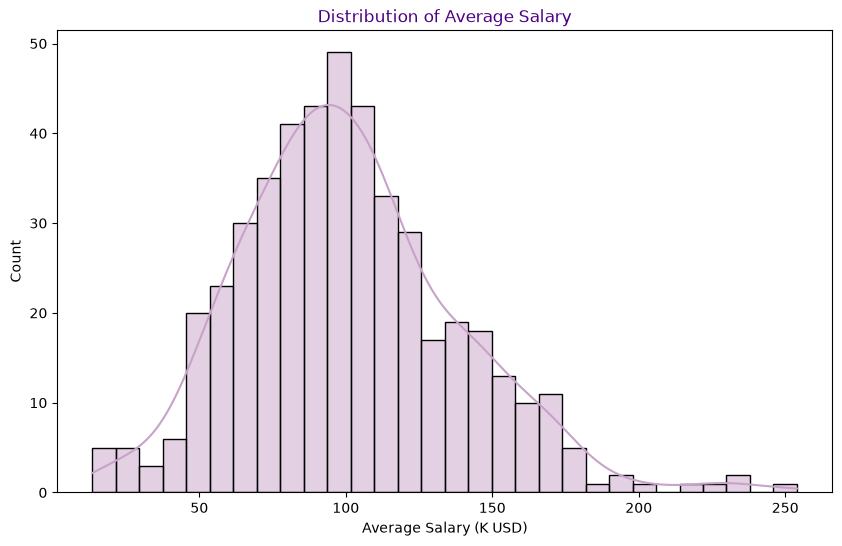

In [5]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Avg_Salary"],
    bins=30,
    color=purple_colors["light_violet"],
    kde=True
)

plt.title("Distribution of Average Salary", color=purple_colors["dark_purple"])
plt.xlabel("Average Salary (K USD)")
plt.ylabel("Count")
plt.show()


## 📊 Chart 2 — Salary by Job Role
*Dashboard-ready — strongest insight chart*

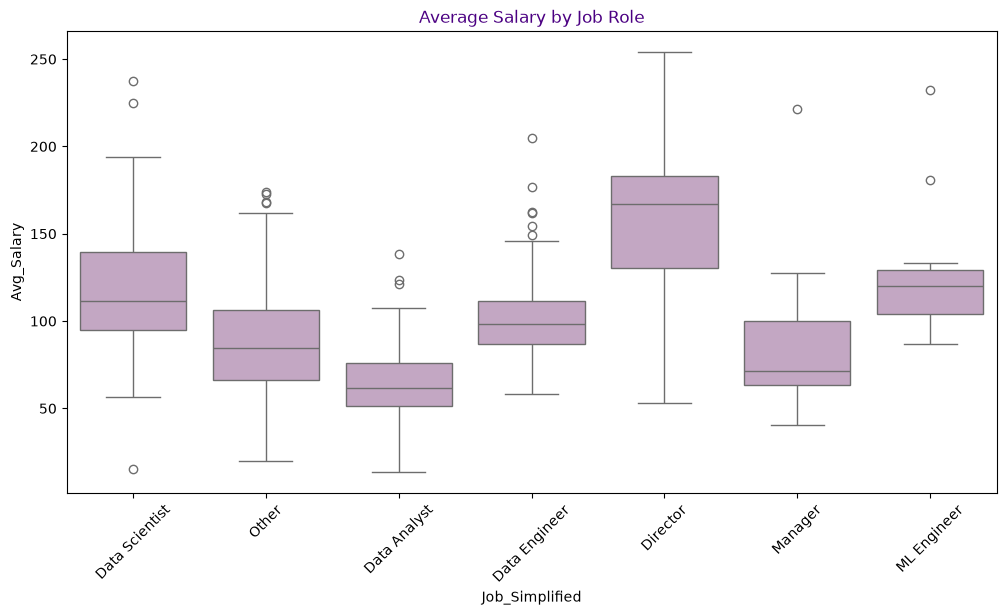

In [6]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Job_Simplified",
    y="Avg_Salary",
    color=purple_colors["light_violet"]
)

plt.xticks(rotation=45)
plt.title("Average Salary by Job Role", color=purple_colors["dark_purple"])
plt.show()


## 📊 Chart 3 — Job Role Distribution
*Dashboard-ready*

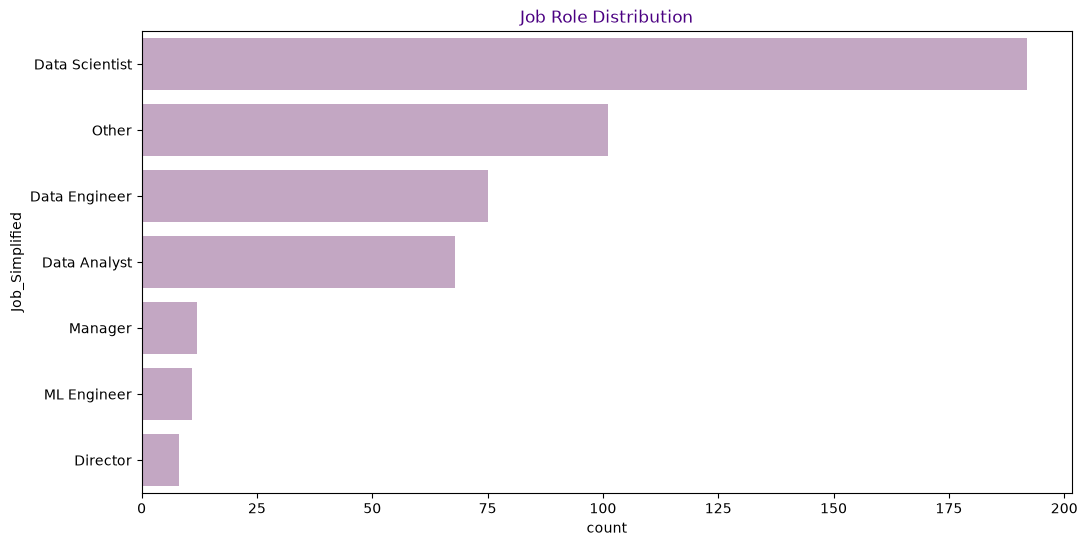

In [7]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    y="Job_Simplified",
    order=df["Job_Simplified"].value_counts().index,
    color=purple_colors["light_violet"]
)

plt.title("Job Role Distribution", color=purple_colors["dark_purple"])
plt.show()


## 📊 Chart 4 — Top Skills Required
*Dashboard-ready — classic, high-impact chart for this project type*

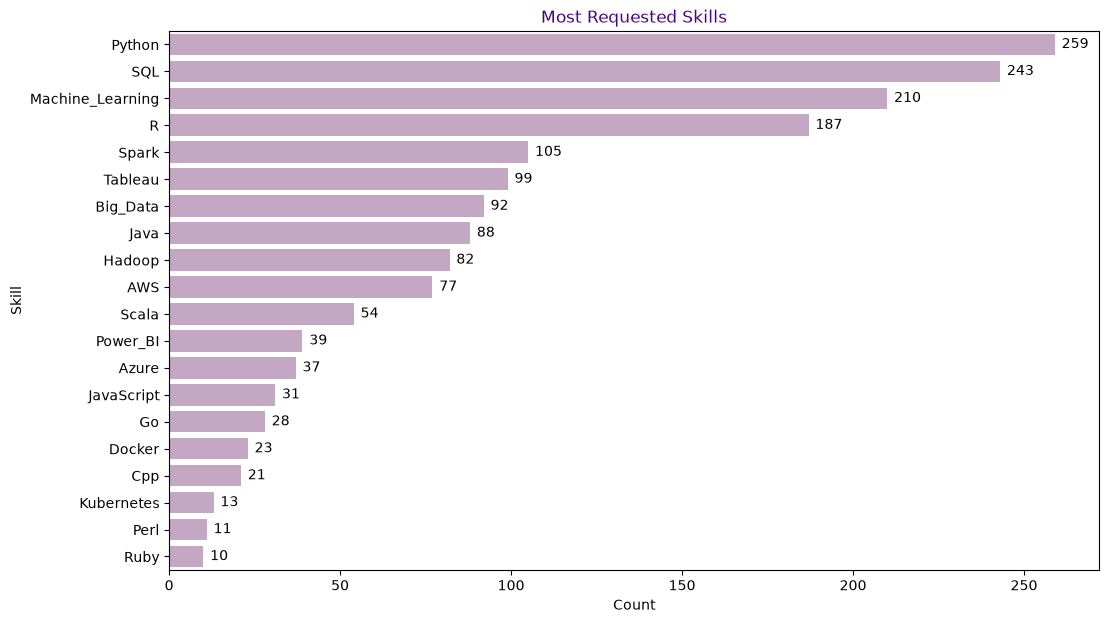

In [8]:
skill_columns = [col for col in df.columns if col.endswith("_yn")]

skill_counts = (
    df[skill_columns]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
skill_counts.columns = ["Skill", "Count"]
skill_counts["Skill"] = skill_counts["Skill"].str.replace("_yn", "")

plt.figure(figsize=(12, 7))

bar = sns.barplot(
    data=skill_counts,
    x="Count",
    y="Skill",
    color=purple_colors["light_violet"]
)

for i, value in enumerate(skill_counts["Count"]):
    bar.text(value + 2, i, str(value), va="center")

plt.title("Most Requested Skills", color=purple_colors["dark_purple"])
plt.show()


In [9]:
print(df.filter(regex="_yn$").columns.tolist())

['Python_yn', 'Java_yn', 'R_yn', 'SQL_yn', 'Cpp_yn', 'JavaScript_yn', 'Ruby_yn', 'Perl_yn', 'Scala_yn', 'Go_yn', 'AWS_yn', 'Azure_yn', 'Spark_yn', 'Hadoop_yn', 'Docker_yn', 'Kubernetes_yn', 'Tableau_yn', 'Power_BI_yn', 'Machine_Learning_yn', 'Big_Data_yn']


## 📊 Chart 5 — Top Hiring States
*Dashboard-ready*

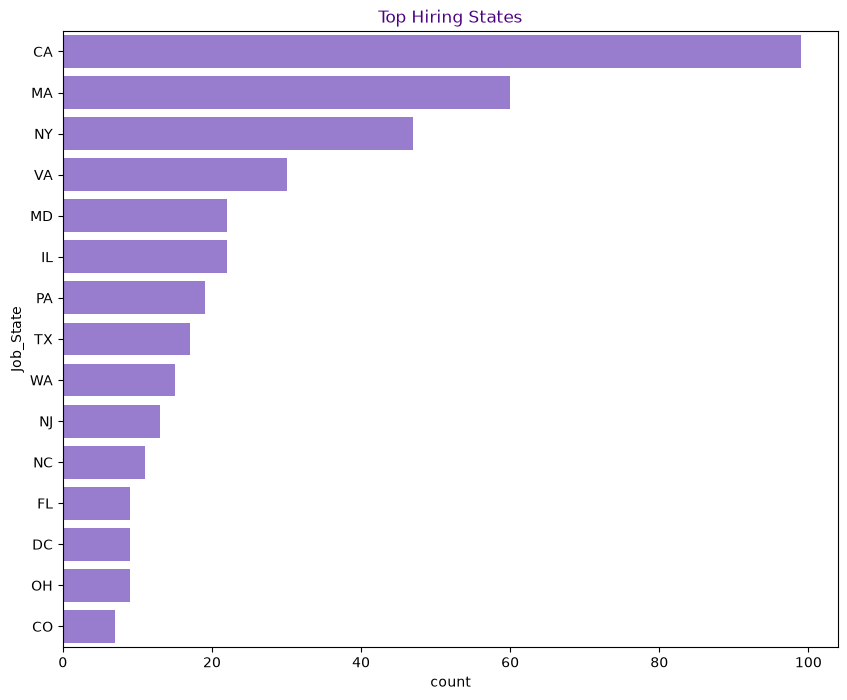

In [11]:
plt.figure(figsize=(10, 8))

sns.countplot(
    data=df,
    y="Job_State",
    order=df["Job_State"].value_counts().head(15).index,
    color=purple_colors["mauve"]
)

plt.title("Top Hiring States", color=purple_colors["dark_purple"])
plt.show()


## 📊 Chart 6 — Experience Required
*Dashboard-ready*

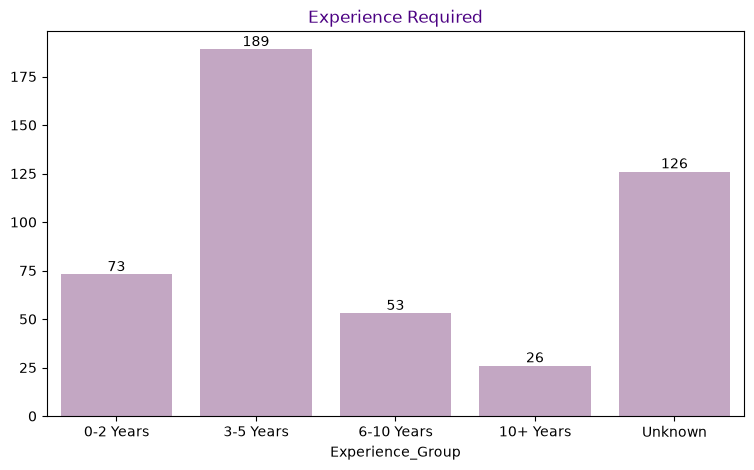

In [12]:
experience_counts = (
    df["Experience_Group"]
    .value_counts()
    .reindex(["0-2 Years", "3-5 Years", "6-10 Years", "10+ Years", "Unknown"])
)

plt.figure(figsize=(9, 5))

bar = sns.barplot(
    x=experience_counts.index,
    y=experience_counts.values,
    color=purple_colors["light_violet"]
)

for i, value in enumerate(experience_counts.values):
    bar.text(i, value, str(value), ha="center", va="bottom")

plt.title("Experience Required", color=purple_colors["dark_purple"])
plt.show()


## 📊 Chart 7 — Remote vs In-Person
*Dashboard-ready*

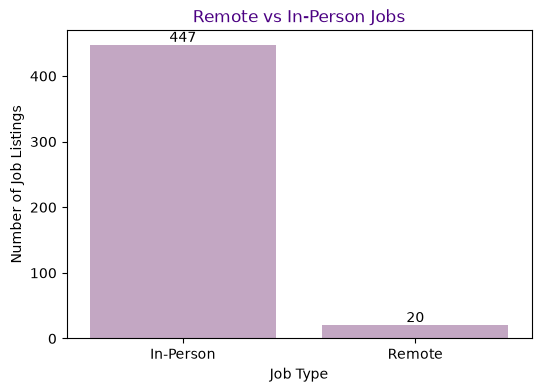

In [13]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x="Remote_Job",
    color=purple_colors["light_violet"]
)

plt.xticks([0, 1], ["In-Person", "Remote"])

# Add count labels on bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Remote vs In-Person Jobs", color=purple_colors["dark_purple"])
plt.xlabel("Job Type")
plt.ylabel("Number of Job Listings")

plt.show()

## Summary

### Final Dashboard Chart Set (7 + Key Metrics)
1. Key Metrics — total listings, avg salary, avg rating, % remote, top skill
2. Salary Distribution
3. Salary by Job Role
4. Job Role Distribution
5. Top Skills Required
6. Top Hiring States
7. Experience Required
8. Remote vs In-Person

